# Interacting with prop datasets

To know
- Distribution of lengths -> compute cut-offs
- Distribution of splits -> compute splits

In [1]:
from multiprocessing import Pool

import datasets
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer
from tqdm import tqdm

from prop import *

In [14]:
# ds_path = full_text_ds_path
ds_path = '/n/home09/wlt/scratch/data/prop_gen/data/hf_full_text'
ds = datasets.load_from_disk(ds_path)
ds

DatasetDict({
    True_2: Dataset({
        features: ['is_true', 'length', 'ops', 'prompt', 'completion'],
        num_rows: 202317
    })
    False_2: Dataset({
        features: ['is_true', 'length', 'ops', 'prompt', 'completion'],
        num_rows: 176243
    })
    True_3: Dataset({
        features: ['is_true', 'length', 'ops', 'prompt', 'completion'],
        num_rows: 157035
    })
    False_3: Dataset({
        features: ['is_true', 'length', 'ops', 'prompt', 'completion'],
        num_rows: 216163
    })
    True_4: Dataset({
        features: ['is_true', 'length', 'ops', 'prompt', 'completion'],
        num_rows: 165150
    })
    False_4: Dataset({
        features: ['is_true', 'length', 'ops', 'prompt', 'completion'],
        num_rows: 208434
    })
    True_5: Dataset({
        features: ['is_true', 'length', 'ops', 'prompt', 'completion'],
        num_rows: 154870
    })
    False_5: Dataset({
        features: ['is_true', 'length', 'ops', 'prompt', 'completion'],
      

In [3]:
ds.cleanup_cache_files()

{'True_9': 0,
 'True_143': 0,
 'False_143': 0,
 'True_142': 0,
 'True_145': 0,
 'True_144': 0,
 'True_149': 0,
 'True_146': 0,
 'True_147': 0,
 'True_148': 0,
 'False_152': 0,
 'False_172': 0,
 'False_209': 0,
 'False_210': 0,
 'False_211': 0,
 'False_212': 0,
 'False_213': 0,
 'False_104': 0,
 'False_105': 0,
 'False_361': 0,
 'False_363': 0,
 'False_96': 0,
 'False_100': 0,
 'False_112': 0,
 'False_113': 0,
 'False_114': 0,
 'False_115': 0,
 'False_170': 0,
 'False_287': 0,
 'False_290': 0,
 'False_293': 0,
 'False_490': 0,
 'False_491': 0,
 'False_493': 0,
 'False_489': 0,
 'False_488': 0,
 'False_496': 0,
 'False_492': 0,
 'False_494': 0,
 'False_499': 0,
 'False_495': 0,
 'False_498': 0,
 'False_497': 0,
 'False_485': 0,
 'False_487': 0,
 'False_618': 0,
 'False_614': 0,
 'False_617': 0,
 'False_620': 0,
 'False_619': 0,
 'False_621': 0,
 'False_622': 0,
 'False_625': 0,
 'False_980': 0,
 'False_983': 0,
 'False_982': 0,
 'False_985': 0,
 'False_984': 0,
 'False_987': 0,
 'True_11

Text(0, 0.5, 'number of examples')

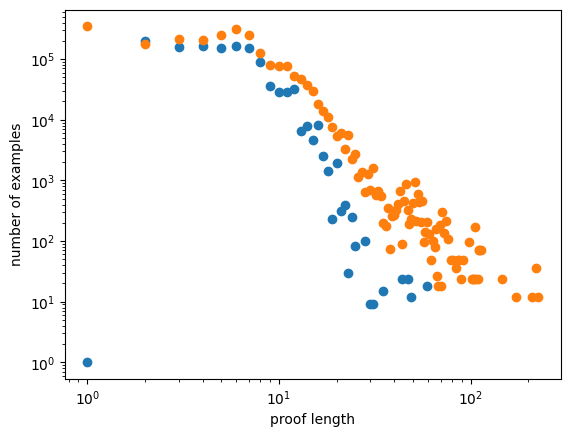

In [15]:
t_vals = []
f_vals = []
a_vals = {}

for k, v in ds.items():
    name, num = k.split('_')

    if name == 'True':
        t_vals.append((int(num), len(v)))
    else:
        f_vals.append((int(num), len(v)))
    
    if int(num) not in a_vals:
        a_vals[int(num)] = len(v)
    else:
        a_vals[int(num)] += len(v)
        

a_vals = list(a_vals.items())

# <codecell>
import matplotlib.pyplot as plt

t_idx, t_lens = np.array(t_vals).T
f_idx, f_lens = np.array(f_vals).T
a_idx, a_lens = np.array(a_vals).T

plt.scatter(t_idx, t_lens)
plt.scatter(f_idx, f_lens)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('proof length')
plt.ylabel('number of examples')

prop | t_idx | f_idx | a_idx
------------------------------
 0.2:     2      1      2
 0.4:     3      4      3
 0.5:     4      4      4
 0.6:     5      5      5
 0.8:     7      8      7
 0.9:     8     11     10
0.95:    11     14     13


Text(0, 0.5, 'cumulative proportion of examples')

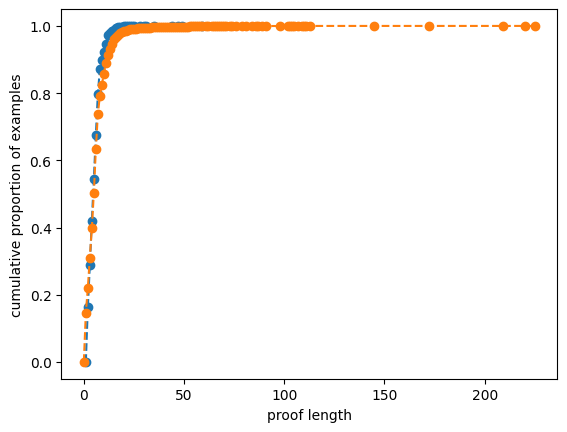

In [16]:
t_sort_idx = np.argsort(t_idx)
t_cum = np.cumsum(t_lens[t_sort_idx]) / np.sum(t_lens)

f_sort_idx = np.argsort(f_idx)
f_cum = np.cumsum(f_lens[f_sort_idx]) / np.sum(f_lens)

a_sort_idx = np.argsort(a_idx)
a_cum = np.cumsum(a_lens[a_sort_idx]) / np.sum(a_lens)

plt.plot(np.sort(t_idx), t_cum, 'o--')
plt.plot(np.sort(f_idx), f_cum, 'o--')

props = [0.2, 0.4, 0.5, 0.6, 0.8, 0.9, 0.95]

t_idxs = []
f_idxs = []
a_idxs = []

for p in props:
    idx = np.sum(t_cum < p) - 1
    t_idxs.append(t_idx[t_sort_idx][idx].item())
    
    idx = np.sum(f_cum < p) - 1
    f_idxs.append(f_idx[f_sort_idx][idx].item())
    
    idx = np.sum(a_cum < p) - 1
    a_idxs.append(a_idx[a_sort_idx][idx].item())

print(f'prop | t_idx | f_idx | a_idx')
print('------------------------------')
for prop, t, f, a in zip(props, t_idxs, f_idxs, a_idxs):
    print(f'{prop:4}: {t:5} {f:6} {a:6}')

plt.xlabel('proof length')
plt.ylabel('cumulative proportion of examples')

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-Coder-7B')

def to_toks(ex):
    inp_and_proof_toks = tokenizer(ex['prompt'] + ex['completion'], return_attention_mask=False)

    return {
        'tok_len': len(inp_and_proof_toks['input_ids']),
    }

ds = ds.map(to_toks, batched=False, num_proc=16)

In [ ]:
def get_len(ex):
    return ex['tok_len']

all_lens = []
for name, sub_ds in ds.items():
    print(f'info: parsing {name}')
    with Pool(16) as pool:
        lens = pool.map(get_len, sub_ds)
    all_lens.extend(lens)


In [ ]:
plt.hist(all_lens, bins=50)
np.quantile(all_lens, [0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

In [ ]:
max(all_lens)

In [ ]:
example = ds['False_497'][0]
out = tokenizer(example['prompt'] + example['completion'], return_attention_mask=False)
len(out['input_ids'])

## Length distributions for different datasets

Full
```
prop | t_idx | f_idx | a_idx
------------------------------
 0.2:     2      1      2
 0.4:     3      4      3
 0.5:     4      4      4
 0.6:     5      5      5
 0.8:     7      8      7
 0.9:     8     11     10
0.95:    11     14     13
```


Imply
```
prop | t_idx | f_idx | a_idx
------------------------------
 0.2:     2     11      3
 0.4:     3     14      5
 0.5:     3     17      9
 0.6:     3     20     12
 0.8:     5     28     21
 0.9:     8     41     29
0.95:    12     56     42
```


Or
```
prop | t_idx | f_idx | a_idx
------------------------------
 0.2:     3     13      3
 0.4:     5     13      5
 0.5:     6     13      6
 0.6:     7     13      7
 0.8:    10     13     10
 0.9:    12     13     13
0.95:    13     13     14
```

PHP
```
prop | t_idx | f_idx | a_idx
------------------------------
 0.2:    15     55     58
 0.4:    36     55     58
 0.5:    42     71     58
 0.6:    42     71     84
 0.8:    80     92     92
 0.9:    82    100     92
0.95:   143    104    110
```